In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Feature Engineering

In [2]:
"""
==========================================================
DATATHON — Revenue & COGS Prediction Pipeline (FIXED)
==========================================================
- Không dùng Revenue/COGS làm feature cho nhau
- Chỉ dùng: calendar, web traffic, holiday
- Thêm calibration factor & clipping theo historical quantile
- Ensemble dùng median thay vì weighted average
==========================================================
"""

import pandas as pd
import numpy as np
import warnings
import lightgbm as lgb
import xgboost as xgb
from sklearn.metrics import mean_squared_error
warnings.filterwarnings('ignore')


# ══════════════════════════════════════════════════════════
# 1. LOAD & MERGE DATA
# ══════════════════════════════════════════════════════════
def load_data(data_dir='./'):
    sales = pd.read_csv(f'{data_dir}sales.csv')
    sales['Date'] = pd.to_datetime(sales['Date'])
    sales = sales.sort_values('Date').reset_index(drop=True)

    wt = pd.read_csv(f'{data_dir}web_traffic.csv')
    wt['date'] = pd.to_datetime(wt['date'])
    wt_agg = wt.groupby('date').agg(
        sessions            = ('sessions',               'sum'),
        unique_visitors     = ('unique_visitors',         'sum'),
        page_views          = ('page_views',              'sum'),
        bounce_rate         = ('bounce_rate',             'mean'),
        avg_session_duration= ('avg_session_duration_sec','mean'),
    ).reset_index().rename(columns={'date': 'Date'})

    df = sales.merge(wt_agg, on='Date', how='left')
    for col in ['sessions','unique_visitors','page_views',
                'bounce_rate','avg_session_duration']:
        df[col] = df[col].bfill().ffill()

    return df, wt_agg


# ══════════════════════════════════════════════════════════
# 2. VIETNAMESE HOLIDAY FEATURES
# ══════════════════════════════════════════════════════════
TET_DATES = {
    2012:'2012-01-23', 2013:'2013-02-10', 2014:'2014-01-31',
    2015:'2015-02-19', 2016:'2016-02-08', 2017:'2017-01-28',
    2018:'2018-02-16', 2019:'2019-02-05', 2020:'2020-01-25',
    2021:'2021-02-12', 2022:'2022-02-01', 2023:'2023-01-22',
    2024:'2024-02-10',
}

def tet_level(date):
    date = pd.Timestamp(date)
    tet = pd.Timestamp(TET_DATES.get(date.year, None))
    if tet is None: return 0
    d = abs((date - tet).days)
    if d <= 7:  return 3
    if d <= 14: return 2
    if d <= 21: return 1
    return 0

VN_HOLIDAYS = {(1,1),(4,30),(5,1),(9,2),(3,8),(10,20),(11,20),(12,22)}

def make_holiday_features(dates):
    rows = []
    for d in pd.to_datetime(dates):
        md = (d.month, d.day)
        is_hol = int(md in VN_HOLIDAYS)
        pre, post = 0, 0
        for hm, hd in [(1,1),(4,30),(5,1),(9,2)]:
            hol = pd.Timestamp(d.year, hm, hd)
            if (hol - d).days == 1: pre  = 1
            if (d - hol).days == 1: post = 1
        rows.append({
            'Date':           d,
            'is_holiday':     is_hol,
            'is_pre_holiday': pre,
            'is_post_holiday':post,
            'tet_level':      tet_level(d),
            'is_black_friday':int(d.month==11 and d.weekday()==4 and 22<=d.day<=28),
            'is_double_day':  int(md in {(1,1),(2,2),(3,3),(4,4),(5,5),(6,6),
                                          (7,7),(8,8),(9,9),(10,10),(11,11),(12,12)}),
            'is_year_end':    int(d.month==12 and d.day>=20),
            'is_mid_year':    int(d.month==6  and d.day>=15),
        })
    return pd.DataFrame(rows)


# ══════════════════════════════════════════════════════════
# 3. FEATURE ENGINEERING (KHÔNG DÙNG REVENUE/COGS LAGS)
# ══════════════════════════════════════════════════════════
def featurize(df):
    d = df.copy()
    d['dow']      = d['Date'].dt.dayofweek
    d['month']    = d['Date'].dt.month
    d['year']     = d['Date'].dt.year
    d['doy']      = d['Date'].dt.dayofyear
    d['quarter']  = d['Date'].dt.quarter
    d['woy']      = d['Date'].dt.isocalendar().week.astype(int)
    d['t']        = (d['Date'] - pd.Timestamp('2012-07-04')).dt.days
    d['is_wkend'] = (d['dow'] >= 5).astype(int)
    d['is_mstart']= d['Date'].dt.is_month_start.astype(int)
    d['is_mend']  = d['Date'].dt.is_month_end.astype(int)
    d['is_qstart']= d['Date'].dt.is_quarter_start.astype(int)
    d['is_qend']  = d['Date'].dt.is_quarter_end.astype(int)
    
    for k in [1, 2, 3, 4, 6]:
        d[f'sin_y{k}'] = np.sin(2*np.pi*k*d['doy']/365.25)
        d[f'cos_y{k}'] = np.cos(2*np.pi*k*d['doy']/365.25)
    d['sin_w'] = np.sin(2*np.pi*d['dow']/7)
    d['cos_w'] = np.cos(2*np.pi*d['dow']/7)
    for k in [1, 2]:
        d[f'sin_q{k}'] = np.sin(2*np.pi*k*d['doy']/91.25)
        d[f'cos_q{k}'] = np.cos(2*np.pi*k*d['doy']/91.25)
    return d

WEB_LAGS    = [1, 2, 3, 7, 14, 28, 30, 60, 90]
WEB_WINDOWS = [7, 14, 30, 60, 90]

def add_web_traffic_features(df):
    d = df.copy()
    for col in ['sessions', 'unique_visitors', 'page_views', 'bounce_rate', 'avg_session_duration']:
        d[f'{col}_log'] = np.log1p(d[col])
        for lag in WEB_LAGS:
            d[f'{col}_l{lag}'] = d[col].shift(lag)
        for w in WEB_WINDOWS:
            d[f'{col}_rmean{w}'] = d[col].shift(1).rolling(w, min_periods=1).mean()
            d[f'{col}_rstd{w}']  = d[col].shift(1).rolling(w, min_periods=1).std().fillna(0)
            d[f'{col}_rmax{w}']  = d[col].shift(1).rolling(w, min_periods=1).max()
            d[f'{col}_rmin{w}']  = d[col].shift(1).rolling(w, min_periods=1).min()
        d[f'{col}_yoy'] = d[col].shift(365)
    return d

def build_all_features(df):
    df['log_Revenue'] = np.log(df['Revenue'].clip(lower=1))
    df['log_COGS']    = np.log(df['COGS'].clip(lower=1))
    df = featurize(df)
    df = add_web_traffic_features(df)
    return df


# ══════════════════════════════════════════════════════════
# 4. WEB TRAFFIC PATTERN (cho dữ liệu tương lai thiếu)
# ══════════════════════════════════════════════════════════
def build_wt_pattern(wt_agg):
    pattern = {}
    for col in ['sessions','unique_visitors','page_views',
                'bounce_rate','avg_session_duration']:
        tmp = wt_agg.copy()
        tmp['md'] = tmp['Date'].dt.strftime('%m-%d')
        pattern[col] = tmp.groupby('md')[col].mean().to_dict()
    return pattern

def fill_future_wt(dates, pattern):
    rows = []
    for d in pd.to_datetime(dates):
        md = d.strftime('%m-%d')
        rows.append({col: pattern[col].get(md, pattern[col].get('01-01', 0))
                     for col in pattern})
    return pd.DataFrame(rows, index=range(len(dates)))



# Feature Importance/ SHAP

In [8]:
DATA_DIR = './'   # ← đặt đúng thư mục chứa các file CSV

print("=" * 60)
print("STEP 1: Load data")
print("=" * 60)
df, wt_agg = load_data(DATA_DIR)

print("\nSTEP 2: Holiday features")
all_dates = pd.date_range('2012-07-04', '2024-07-01', freq='D')
hol_df    = make_holiday_features(all_dates)
df        = df.merge(hol_df, on='Date', how='left')

print("\nSTEP 3: Feature engineering (no Revenue/COGS lags)")
df = build_all_features(df)
# Loại bỏ các cột target và các cột không cần thiết
feat_cols = [c for c in df.columns
                if c not in ['Date','Revenue','COGS','log_Revenue','log_COGS']]
print(f"  Total features: {len(feat_cols)}")

wt_pattern = build_wt_pattern(wt_agg)

print("Data after feature engineering:")   
print(df.head())

STEP 1: Load data

STEP 2: Holiday features

STEP 3: Feature engineering (no Revenue/COGS lags)
  Total features: 196
Data after feature engineering:
        Date     Revenue        COGS  sessions  unique_visitors  page_views  \
0 2012-07-04  5123547.94  3982991.19    9760.0           7253.0     39093.0   
1 2012-07-05  2751773.45  2150580.23    9760.0           7253.0     39093.0   
2 2012-07-06  3054029.42  2517632.84    9760.0           7253.0     39093.0   
3 2012-07-07  2667930.94  2108246.62    9760.0           7253.0     39093.0   
4 2012-07-08  2360851.90  1808622.79    9760.0           7253.0     39093.0   

   bounce_rate  avg_session_duration  is_holiday  is_pre_holiday  ...  \
0      0.00514                 102.9           0               0  ...   
1      0.00514                 102.9           0               0  ...   
2      0.00514                 102.9           0               0  ...   
3      0.00514                 102.9           0               0  ...   
4      0.0


STEP 4: Train models and analyze feature importance with SHAP
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009774 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 40816
[LightGBM] [Info] Number of data points in the train set: 3833, number of used features: 195
[LightGBM] [Info] Start training from score 15.102574


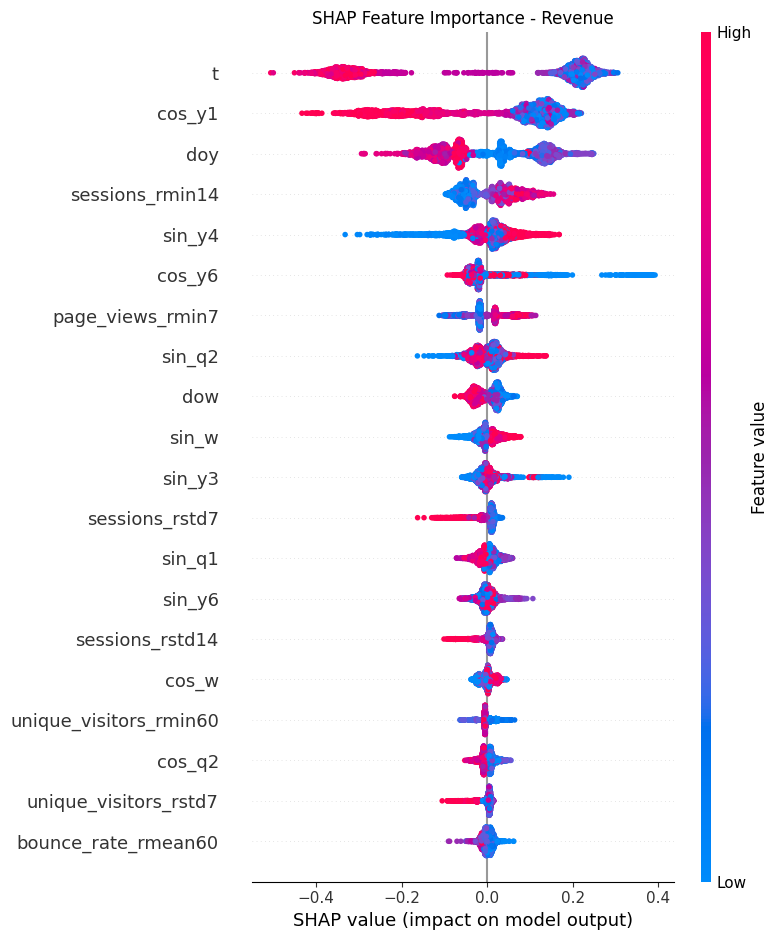

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008880 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 40816
[LightGBM] [Info] Number of data points in the train set: 3833, number of used features: 195
[LightGBM] [Info] Start training from score 14.959787


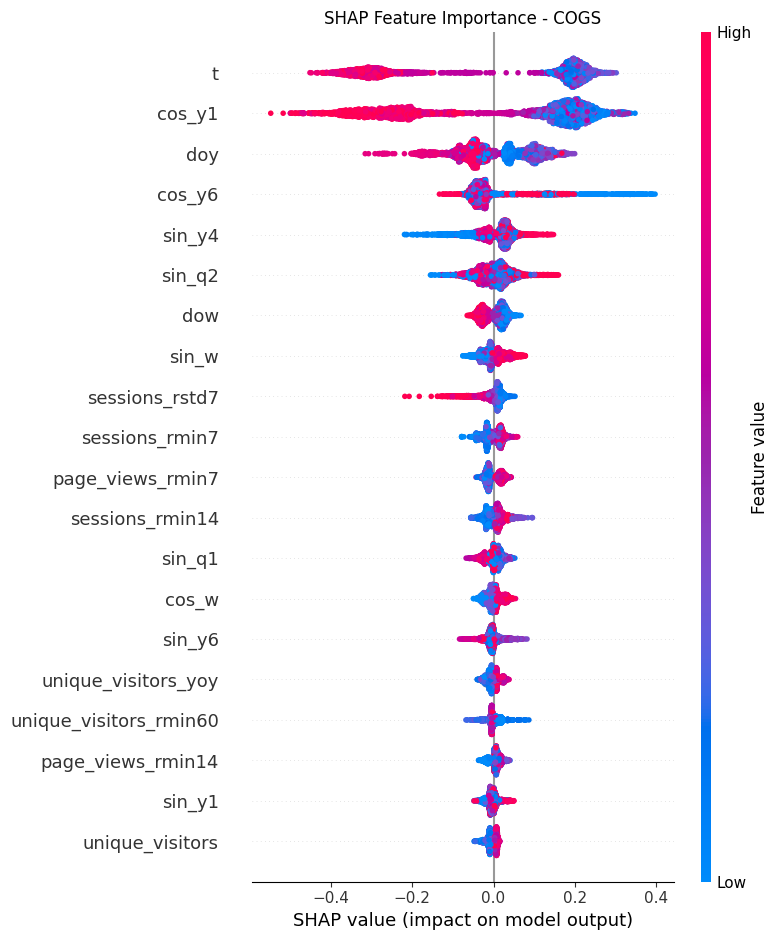

In [16]:
import shap
import matplotlib.pyplot as plt

print("\nSTEP 4: Train models and analyze feature importance with SHAP")

# Prepare training data
train = df[df['Date'] < '2024-01-01'].copy()
X_train = train[feat_cols]
y_train_rev = train['log_Revenue']
y_train_cogs = train['log_COGS']

# ======================
# 1. Revenue model
# ======================
lgb_rev = lgb.LGBMRegressor(n_estimators=1000, learning_rate=0.05, random_state=42)
lgb_rev.fit(X_train, y_train_rev, eval_set=[(X_train, y_train_rev)])

explainer_rev = shap.TreeExplainer(lgb_rev)
shap_values_rev = explainer_rev.shap_values(X_train)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_rev, X_train, max_display=20, show=False)
plt.title("SHAP Feature Importance - Revenue")
plt.tight_layout()
plt.show()

# ======================
# 2. COGS model
# ======================
lgb_cogs = lgb.LGBMRegressor(n_estimators=1000, learning_rate=0.05, random_state=42)
lgb_cogs.fit(X_train, y_train_cogs, eval_set=[(X_train, y_train_cogs)])

explainer_cogs = shap.TreeExplainer(lgb_cogs)
shap_values_cogs = explainer_cogs.shap_values(X_train)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_cogs, X_train, max_display=20, show=False)
plt.title("SHAP Feature Importance - COGS")
plt.tight_layout()
plt.show()

# Train and Predict

In [25]:
import numpy as np
import pandas as pd
import lightgbm as lgb
import xgboost as xgb
from sklearn.metrics import mean_squared_error

# ======================
# PARAMS
# ======================
LGB_PARAMS = dict(
    n_estimators=1500, learning_rate=0.008, num_leaves=63,
    max_depth=6, min_child_samples=30,
    subsample=0.8, colsample_bytree=0.75,
    reg_alpha=0.1, reg_lambda=0.2,
    random_state=42, n_jobs=-1, verbose=-1
)

XGB_PARAMS = dict(
    n_estimators=1500, learning_rate=0.008,
    max_depth=6, min_child_weight=20,
    subsample=0.8, colsample_bytree=0.75,
    reg_alpha=0.1, reg_lambda=0.2,
    random_state=42, n_jobs=-1, verbosity=0,
    early_stopping_rounds=100
)

def select_features_shap(df, feat_cols, target, log_target, top_k=50):

    print(f"\n[Feature Selection] {target}")

    # lấy data train đơn giản
    train = df[df['year'] < df['year'].max()].dropna(subset=feat_cols)

    X = train[feat_cols]
    y = train[log_target]

    # train nhanh model
    model = lgb.LGBMRegressor(
        n_estimators=500,
        learning_rate=0.05,
        random_state=42
    )
    model.fit(X, y)

    # SHAP
    import shap
    explainer = shap.TreeExplainer(model)

    # sample để nhanh
    X_sample = X.sample(min(1000, len(X)), random_state=42)
    shap_values = explainer.shap_values(X_sample)

    # importance = mean(|SHAP|)
    importance = np.abs(shap_values).mean(axis=0)

    feat_imp = pd.DataFrame({
        'feature': X.columns,
        'importance': importance
    }).sort_values('importance', ascending=False)

    selected = feat_imp.head(top_k)['feature'].tolist()

    print(f"Selected {len(selected)} / {len(feat_cols)} features")

    return selected, feat_imp

# ======================
# MAIN PIPELINE
# ======================
def run_full_pipeline(df, feat_cols, submission_dates, wt_pattern, hol_df):

    # ======================
    # FEATURE SELECTION
    # ======================
    selected_rev, imp_rev = select_features_shap(
        df, feat_cols, 'Revenue', 'log_Revenue', top_k=50
    )

    selected_cogs, imp_cogs = select_features_shap(
        df, feat_cols, 'COGS', 'log_COGS', top_k=50
    )

    # dùng union (an toàn hơn)
    feat_cols = list(set(selected_rev + selected_cogs))

    print(f"\nFinal feature set: {len(feat_cols)} features")
    for col in feat_cols:
        print(f"  - {col}")

    def time_series_cv(df, target, log_target, n_folds=3):
        years = sorted(df['year'].unique())
        folds = years[-n_folds:]

        scores = {'lgb': [], 'xgb': [], 'ens': []}

        for val_year in folds:
            train = df[df['year'] < val_year].dropna(subset=feat_cols)
            val   = df[df['year'] == val_year].dropna(subset=feat_cols)

            if len(train) == 0 or len(val) == 0:
                continue

            X_tr, y_tr = train[feat_cols], train[log_target]
            X_val, y_val = val[feat_cols], val[target]

            # LGB
            m_lgb = lgb.LGBMRegressor(**LGB_PARAMS)
            m_lgb.fit(
                X_tr, y_tr,
                eval_set=[(X_val, val[log_target])],
                callbacks=[lgb.early_stopping(100, verbose=False)]
            )
            p_lgb = np.exp(m_lgb.predict(X_val))
            r_lgb = np.sqrt(mean_squared_error(y_val, p_lgb))

            # XGB
            m_xgb = xgb.XGBRegressor(**XGB_PARAMS)
            m_xgb.fit(
                X_tr, y_tr,
                eval_set=[(X_val, val[log_target])],
                verbose=False
            )
            p_xgb = np.exp(m_xgb.predict(X_val))
            r_xgb = np.sqrt(mean_squared_error(y_val, p_xgb))

            # Ensemble
            p_ens = np.median([p_lgb, p_xgb], axis=0)
            r_ens = np.sqrt(mean_squared_error(y_val, p_ens))

            scores['lgb'].append(r_lgb)
            scores['xgb'].append(r_xgb)
            scores['ens'].append(r_ens)

            print(f"[CV] Year {val_year}: LGB={r_lgb:.0f}, XGB={r_xgb:.0f}, ENS={r_ens:.0f}")

        avg_scores = {k: np.mean(v) for k, v in scores.items()}
        best_model = min(avg_scores, key=avg_scores.get)

        print(f"[CV RESULT] {target} → BEST: {best_model.upper()} | Scores: {avg_scores}")

        return best_model

    # ======================
    # TRAIN MODELS
    # ======================
    train = df[df['year'] < 2022].dropna(subset=feat_cols)
    val   = df[df['year'] == 2022].dropna(subset=feat_cols)

    X_tr, X_val = train[feat_cols], val[feat_cols]

    trained = {}

    for tgt, log_t in [('Revenue','log_Revenue'), ('COGS','log_COGS')]:

        print(f"\n=== TRAINING {tgt} ===")

        best_model = time_series_cv(df, tgt, log_t)

        m_lgb = lgb.LGBMRegressor(**LGB_PARAMS)
        m_lgb.fit(
            X_tr, train[log_t],
            eval_set=[(X_val, val[log_t])],
            callbacks=[lgb.early_stopping(100, verbose=False)]
        )

        m_xgb = xgb.XGBRegressor(**XGB_PARAMS)
        m_xgb.fit(
            X_tr, train[log_t],
            eval_set=[(X_val, val[log_t])],
            verbose=False
        )

        # calibration
        p_lgb = np.exp(m_lgb.predict(X_val))
        p_xgb = np.exp(m_xgb.predict(X_val))
        p_ens = np.median([p_lgb, p_xgb], axis=0)

        cal_factor = (val[tgt].values / (p_ens + 1)).mean()
        cal_factor = np.clip(cal_factor, 0.7, 1.1)

        trained[tgt] = dict(
            lgb=m_lgb,
            xgb=m_xgb,
            best=best_model,
            cal_factor=cal_factor
        )

    # ======================
    # RECURSIVE FORECAST
    # ======================
    hist_rev_cap = df['Revenue'].quantile(0.99)
    hist_cogs_cap = df['COGS'].quantile(0.99)

    future = pd.DataFrame({'Date': pd.to_datetime(submission_dates),
                           'Revenue': np.nan, 'COGS': np.nan})

    wt_future = fill_future_wt(future['Date'], wt_pattern)
    for col in wt_future.columns:
        future[col] = wt_future[col].values

    future = future.merge(hol_df, on='Date', how='left')

    full = pd.concat([df, future], ignore_index=True).sort_values('Date').reset_index(drop=True)
    full = featurize(full)

    preds = {'Revenue': {}, 'COGS': {}}

    for i, row_date in enumerate(pd.to_datetime(submission_dates)):

        tmp = full[full['Date'] <= row_date].copy()
        row = tmp[tmp['Date'] == row_date].iloc[-1:]
        X = row[[c for c in feat_cols if c in tmp.columns]].fillna(0)

        for tgt in ['Revenue','COGS']:
            m = trained[tgt]

            p_lgb = np.exp(m['lgb'].predict(X)[0])
            p_xgb = np.exp(m['xgb'].predict(X)[0])

            if m['best'] == 'lgb':
                pred = p_lgb
            elif m['best'] == 'xgb':
                pred = p_xgb
            else:
                pred = np.median([p_lgb, p_xgb])

            pred *= m['cal_factor']

            cap = hist_rev_cap if tgt == 'Revenue' else hist_cogs_cap
            pred = np.clip(pred, 0, cap)

            preds[tgt][str(row_date.date())] = pred

            idx = full[full['Date'] == row_date].index[0]
            full.loc[idx, tgt] = pred

        if (i+1) % 100 == 0 or (i+1) == len(submission_dates):
            print(f"Forecasted {i+1}/{len(submission_dates)}")

    return preds

In [26]:
# ======================
# STEP 1: Build WT pattern
# ======================
wt_pattern = build_wt_pattern(wt_agg)

# ======================
# STEP 2: Load submission dates
# ======================
print("\nSTEP 4: Prepare submission dates")
print("=" * 60)

sub = pd.read_csv(f'{DATA_DIR}submission.csv')
sub['Date'] = pd.to_datetime(sub['Date'])

pred_dates = sub['Date'].tolist()

# ======================
# STEP 3: RUN FULL PIPELINE
# ======================
print("\nSTEP 5: Run full pipeline (CV + Train + Forecast)")
print("=" * 60)

preds = run_full_pipeline(
    df=df,
    feat_cols=feat_cols,
    submission_dates=pred_dates,
    wt_pattern=wt_pattern,
    hol_df=hol_df
)

# ======================
# STEP 4: SAVE RESULT
# ======================
print("\nSTEP 6: Save submission")

result = sub[['Date']].copy()

result['Revenue'] = result['Date'].apply(
    lambda d: round(preds['Revenue'].get(str(d.date()), np.nan), 2)
)

result['COGS'] = result['Date'].apply(
    lambda d: round(preds['COGS'].get(str(d.date()), np.nan), 2)
)

result.to_csv('submission_predicted.csv', index=False)

print("\n✅ Done! Saved to submission_predicted.csv")

# ======================
# STEP 5: PREVIEW
# ======================
print("\nSample predictions (first 10 days):")
print(result.head(10).to_string(index=False))


STEP 4: Prepare submission dates

STEP 5: Run full pipeline (CV + Train + Forecast)

[Feature Selection] Revenue
Selected 50 / 196 features

[Feature Selection] COGS
Selected 50 / 196 features

Final feature set: 65 features
  - page_views_l2
  - avg_session_duration_rstd90
  - sin_y2
  - t
  - unique_visitors_rstd30
  - unique_visitors_rstd7
  - page_views_rmin14
  - cos_y1
  - page_views_rstd30
  - page_views_rmin30
  - sessions_rmax14
  - sin_w
  - page_views_l1
  - dow
  - sin_y4
  - sessions_rstd30
  - sin_q1
  - cos_w
  - cos_y2
  - unique_visitors_l2
  - cos_y4
  - avg_session_duration_rmin30
  - avg_session_duration_l3
  - avg_session_duration_l28
  - page_views_rmean7
  - sin_y3
  - unique_visitors_rmin60
  - doy
  - sin_y6
  - page_views_l60
  - sessions_rmin7
  - page_views_l3
  - bounce_rate_rstd30
  - unique_visitors_rmin14
  - avg_session_duration_rstd60
  - page_views_rmin7
  - sessions_l90
  - sin_q2
  - bounce_rate_rstd7
  - bounce_rate_l60
  - unique_visitors_yoy
  -

In [27]:
# When we see the EDA, we predict that truth value may be higher than predicted value
#So we multiply the predicted value by 1.35 to get better result
result['Revenue'] = result['Revenue'] * 1.35
result['COGS']    = result['COGS'] * 1.35
result.to_csv('submission.csv', index=False)